# 02 — Deterministic Triage Baseline and Guardrails

This notebook validates the finalized deterministic claims-triage baseline,
its controlled tool adapter, and the guardrail that prevents an agent layer
from overriding authoritative eligibility routing.

In [2]:
# ============================================================
# Notebook Setup: Project Root and Imports
# ============================================================

from pathlib import Path
import sys

CURRENT_DIRECTORY = Path.cwd().resolve()

if (CURRENT_DIRECTORY / "src").exists():
    PROJECT_ROOT = CURRENT_DIRECTORY
elif (CURRENT_DIRECTORY.parent / "src").exists():
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' folder. "
        f"Current working directory: {CURRENT_DIRECTORY}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Notebook working directory:", CURRENT_DIRECTORY)
print("Project root:", PROJECT_ROOT)
print("Source folder found:", (PROJECT_ROOT / "src").exists())

Notebook working directory: /Users/sadiqsheik/Documents/MS/IIITB_Course Docs/Capstone Project/BYOC/DP_claims_triage/notebooks
Project root: /Users/sadiqsheik/Documents/MS/IIITB_Course Docs/Capstone Project/BYOC/DP_claims_triage
Source folder found: True


In [3]:
# ============================================================
# OpenAI Setup: Load Local Environment Variables
# ============================================================

import os

from dotenv import load_dotenv

dotenv_path = PROJECT_ROOT / ".env"

if not dotenv_path.exists():
    raise FileNotFoundError(
        f"Expected .env file was not found: {dotenv_path}"
    )

load_dotenv(dotenv_path=dotenv_path, override=False)

api_key_available = bool(os.getenv("OPENAI_API_KEY"))

print("Environment file found:", dotenv_path.exists())
print("OPENAI_API_KEY available:", api_key_available)

if not api_key_available:
    raise EnvironmentError(
        "OPENAI_API_KEY is not available after loading .env."
    )

Environment file found: True
OPENAI_API_KEY available: True


In [4]:
# ============================================================
# Notebook Setup: Load Development Runtime Data
# ============================================================

import pandas as pd

from src.data_loader import load_runtime_data

data = load_runtime_data()

print("Runtime datasets loaded:")
for dataset_name, dataframe in data.items():
    print(f"{dataset_name}: {dataframe.shape[0]:,} rows x {dataframe.shape[1]} columns")

assert "development_claims" in data
assert len(data["development_claims"]) == 165

print("\nDevelopment claims available:", len(data["development_claims"]))

Runtime datasets loaded:
plan_master: 3 rows x 16 columns
coverage_matrix: 18 rows x 11 columns
evidence_requirements: 9 rows x 7 columns
policy_rules: 19 rows x 20 columns
policy_lookup: 120 rows x 18 columns
prior_claims: 112 rows x 16 columns
evidence_bundles: 220 rows x 8 columns
evidence_documents: 283 rows x 14 columns
development_claims: 165 rows x 14 columns
risk_results: 4 rows x 19 columns

Development claims available: 165


In [5]:
from src.agent.response_guardrail import build_guarded_agent_response
from src.tools.deterministic_triage import run_deterministic_triage

print("Deterministic triage tool imported successfully.")
print("Response guardrail imported successfully.")

Deterministic triage tool imported successfully.
Response guardrail imported successfully.


In [6]:
# ============================================================
# Step 28: Response Guardrail Validation
# ============================================================

from src.agent.response_guardrail import build_guarded_agent_response
from src.tools.deterministic_triage import run_deterministic_triage

tool_result = run_deterministic_triage(
    data=data,
    claim_id="CLM-000204",
)

aligned_proposal = {
    "case_summary": (
        "The case was assessed using the deterministic policy workflow."
    ),
    "reviewer_note": (
        "Review the authoritative trace and policy-limit facts."
    ),
    "next_step_message": (
        "Route the case according to the authoritative decision."
    ),
}

override_attempt = {
    "triage_outcome": "PROCEED",
    "triggering_rule_id": "OUT-001",
    "precedence_stage": 6,
    "decision_reason": "The claim has been approved.",
    "case_summary": (
        "The deterministic rule trace identified an annual-limit issue."
    ),
    "unexpected_field": "This field should be ignored.",
}

aligned_result = build_guarded_agent_response(
    tool_result=tool_result,
    proposed_response=aligned_proposal,
)

blocked_result = build_guarded_agent_response(
    tool_result=tool_result,
    proposed_response=override_attempt,
)

assert (
    aligned_result["triage_outcome"]
    == tool_result["deterministic_decision"]["triage_outcome"]
)

assert (
    blocked_result["triage_outcome"]
    == tool_result["deterministic_decision"]["triage_outcome"]
)

assert (
    blocked_result["triggering_rule_id"]
    == tool_result["deterministic_decision"]["triggering_rule_id"]
)

assert (
    blocked_result["authority_guardrail"]["status"]
    == "OVERRIDE_BLOCKED"
)

guardrail_validation_df = pd.DataFrame(
    [
        {
            "scenario": "Aligned explanation",
            "final_outcome": aligned_result["triage_outcome"],
            "final_rule": aligned_result["triggering_rule_id"],
            "guardrail_status": aligned_result[
                "authority_guardrail"
            ]["status"],
            "conflicting_fields": aligned_result[
                "authority_guardrail"
            ]["conflicting_authority_fields"],
        },
        {
            "scenario": "Attempted override",
            "final_outcome": blocked_result["triage_outcome"],
            "final_rule": blocked_result["triggering_rule_id"],
            "guardrail_status": blocked_result[
                "authority_guardrail"
            ]["status"],
            "conflicting_fields": blocked_result[
                "authority_guardrail"
            ]["conflicting_authority_fields"],
        },
    ]
)

display(guardrail_validation_df)

print("Blocked override result:")
print(blocked_result["authority_guardrail"])

,scenario,final_outcome,final_rule,guardrail_status,conflicting_fields
0,Aligned explanation,NOT_ELIGIBLE,LIM-001,ALIGNED,[]
1,Attempted override,NOT_ELIGIBLE,LIM-001,OVERRIDE_BLOCKED,"[triage_outcome, triggering_rule_id, precedenc..."


Blocked override result:
{'status': 'OVERRIDE_BLOCKED', 'authoritative_source': 'deterministic_triage:rules_baseline_v1', 'conflicting_authority_fields': ['triage_outcome', 'triggering_rule_id', 'precedence_stage', 'decision_reason'], 'ignored_agent_fields': ['unexpected_field'], 'authority_notice': 'The deterministic triage decision is authoritative for eligibility routing. Agent-generated content is non-authoritative explanation only.'}


## Validation Result

The deterministic claims-triage baseline, controlled tool adapter, and
response guardrail were validated successfully.

The complete regression suite passed with 19 tests.

The deterministic decision remains authoritative for eligibility routing.
Any future agent or LLM layer may provide explanation and reviewer guidance,
but cannot modify the triage outcome, triggering rule, precedence stage,
decision reason, rule trace, or system limitations.

In [7]:
# ============================================================
# Step 30: Reference Orchestrator Validation
# ============================================================

from pprint import pprint
import pandas as pd

from src.agent.orchestrator import run_guarded_claim_orchestrator


orchestrator_claims = {
    "Clean claim": "CLM-000001",
    "Missing required evidence": "CLM-000117",
    "Risk-triggered claim": "CLM-000180",
    "Annual limit exhausted": "CLM-000204",
}

orchestrator_rows = []

for scenario, claim_id in orchestrator_claims.items():
    workflow_result = run_guarded_claim_orchestrator(
        data=data,
        claim_id=claim_id,
    )

    final_response = workflow_result["final_response"]

    orchestrator_rows.append(
        {
            "scenario": scenario,
            "claim_id": claim_id,
            "triage_outcome": final_response["triage_outcome"],
            "triggering_rule_id": final_response[
                "triggering_rule_id"
            ],
            "guardrail_status": final_response[
                "authority_guardrail"
            ]["status"],
            "proposal_source": workflow_result["workflow_trace"][1][
                "proposal_source"
            ],
            "workflow_nodes": len(workflow_result["workflow_trace"]),
        }
    )

orchestrator_validation_df = pd.DataFrame(orchestrator_rows)

display(orchestrator_validation_df)

print("Example protected workflow result:")
example_result = run_guarded_claim_orchestrator(
    data=data,
    claim_id="CLM-000204",
)

pprint(example_result)

,scenario,claim_id,triage_outcome,triggering_rule_id,guardrail_status,proposal_source,workflow_nodes
0,Clean claim,CLM-000001,PROCEED,OUT-001,ALIGNED,TEMPLATE,4
1,Missing required evidence,CLM-000117,INFO_REQUIRED,EVD-001,ALIGNED,TEMPLATE,4
2,Risk-triggered claim,CLM-000180,MANUAL_REVIEW,ANM-001,ALIGNED,TEMPLATE,4
3,Annual limit exhausted,CLM-000204,NOT_ELIGIBLE,LIM-001,ALIGNED,TEMPLATE,4


Example protected workflow result:
{'agent_proposal': {'case_summary': 'Deterministic triage returned '
                                    'NOT_ELIGIBLE under rule LIM-001. The '
                                    "plan's annual claim allowance is "
                                    'exhausted.',
                    'next_step_message': 'Record the system triage '
                                         'recommendation and follow the '
                                         'approved analyst review or '
                                         'escalation process before any final '
                                         'customer communication.',
                    'reviewer_note': 'This is a system triage recommendation '
                                     'based on the deterministic rule result. '
                                     'An authorised reviewer may apply '
                                     'approved review, escalation, or '
                                

In [8]:
# ============================================================
# Step 33: LangGraph Guarded Workflow Validation
# ============================================================

from pprint import pprint

from src.agent.langgraph_orchestrator import (
    run_langgraph_guarded_claim_triage,
)

langgraph_claims = {
    "Clean claim": "CLM-000001",
    "Missing required evidence": "CLM-000117",
    "Risk-triggered claim": "CLM-000180",
    "Annual limit exhausted": "CLM-000204",
}

langgraph_rows = []

for scenario, claim_id in langgraph_claims.items():
    workflow_result = run_langgraph_guarded_claim_triage(
        data=data,
        claim_id=claim_id,
    )

    final_response = workflow_result["final_response"]

    langgraph_rows.append(
        {
            "scenario": scenario,
            "claim_id": claim_id,
            "triage_outcome": final_response["triage_outcome"],
            "triggering_rule_id": final_response[
                "triggering_rule_id"
            ],
            "guardrail_status": final_response[
                "authority_guardrail"
            ]["status"],
            "proposal_source": workflow_result["workflow_trace"][1][
                "proposal_source"
            ],
            "workflow_nodes": len(workflow_result["workflow_trace"]),
        }
    )

langgraph_validation_df = pd.DataFrame(langgraph_rows)

display(langgraph_validation_df)

print("Example LangGraph protected workflow result:")

example_langgraph_result = run_langgraph_guarded_claim_triage(
    data=data,
    claim_id="CLM-000204",
)

pprint(example_langgraph_result)

,scenario,claim_id,triage_outcome,triggering_rule_id,guardrail_status,proposal_source,workflow_nodes
0,Clean claim,CLM-000001,PROCEED,OUT-001,ALIGNED,TEMPLATE,4
1,Missing required evidence,CLM-000117,INFO_REQUIRED,EVD-001,ALIGNED,TEMPLATE,4
2,Risk-triggered claim,CLM-000180,MANUAL_REVIEW,ANM-001,ALIGNED,TEMPLATE,4
3,Annual limit exhausted,CLM-000204,NOT_ELIGIBLE,LIM-001,ALIGNED,TEMPLATE,4


Example LangGraph protected workflow result:
{'agent_proposal': {'case_summary': 'Deterministic triage returned '
                                    'NOT_ELIGIBLE under rule LIM-001. The '
                                    "plan's annual claim allowance is "
                                    'exhausted.',
                    'next_step_message': 'Record the system triage '
                                         'recommendation and follow the '
                                         'approved analyst review or '
                                         'escalation process before any final '
                                         'customer communication.',
                    'reviewer_note': 'This is a system triage recommendation '
                                     'based on the deterministic rule result. '
                                     'An authorised reviewer may apply '
                                     'approved review, escalation, or '
                      

In [9]:
# ============================================================
# Step 34: Reference Orchestrator vs LangGraph Parity Check
# ============================================================

from src.agent.orchestrator import run_guarded_claim_orchestrator
from src.agent.langgraph_orchestrator import (
    run_langgraph_guarded_claim_triage,
)

parity_claim_ids = [
    "CLM-000001",  # PROCEED
    "CLM-000071",  # Missing incident date
    "CLM-000117",  # Missing evidence
    "CLM-000180",  # Risk trigger
    "CLM-000204",  # Annual limit exhausted
    "CLM-000210",  # Theft limit exhausted
    "CLM-000162",  # Multiple policy match
]

parity_rows = []

for claim_id in parity_claim_ids:
    reference_result = run_guarded_claim_orchestrator(
        data=data,
        claim_id=claim_id,
    )

    langgraph_result = run_langgraph_guarded_claim_triage(
        data=data,
        claim_id=claim_id,
    )

    reference_response = reference_result["final_response"]
    langgraph_response = langgraph_result["final_response"]

    authoritative_fields_match = all(
        reference_response[field_name]
        == langgraph_response[field_name]
        for field_name in [
            "claim_id",
            "triage_outcome",
            "triggering_rule_id",
            "precedence_stage",
            "decision_reason",
            "rule_trace",
            "system_limitations",
            "decision_support_only",
        ]
    )

    agent_content_match = (
        reference_response["agent_content"]
        == langgraph_response["agent_content"]
    )

    guardrail_match = (
        reference_response["authority_guardrail"]
        == langgraph_response["authority_guardrail"]
    )

    parity_rows.append(
        {
            "claim_id": claim_id,
            "outcome": langgraph_response["triage_outcome"],
            "rule": langgraph_response["triggering_rule_id"],
            "authoritative_fields_match": authoritative_fields_match,
            "agent_content_match": agent_content_match,
            "guardrail_match": guardrail_match,
            "overall_match": (
                authoritative_fields_match
                and agent_content_match
                and guardrail_match
            ),
        }
    )

parity_df = pd.DataFrame(parity_rows)

display(parity_df)

assert parity_df["overall_match"].all()

print(
    "Parity check passed: LangGraph and reference orchestrator "
    "returned equivalent protected responses for all selected claims."
)

,claim_id,outcome,rule,authoritative_fields_match,agent_content_match,guardrail_match,overall_match
0,CLM-000001,PROCEED,OUT-001,True,True,True,True
1,CLM-000071,INFO_REQUIRED,ELG-001,True,True,True,True
2,CLM-000117,INFO_REQUIRED,EVD-001,True,True,True,True
3,CLM-000180,MANUAL_REVIEW,ANM-001,True,True,True,True
4,CLM-000204,NOT_ELIGIBLE,LIM-001,True,True,True,True
5,CLM-000210,NOT_ELIGIBLE,LIM-002,True,True,True,True
6,CLM-000162,MANUAL_REVIEW,DATA-002,True,True,True,True


Parity check passed: LangGraph and reference orchestrator returned equivalent protected responses for all selected claims.


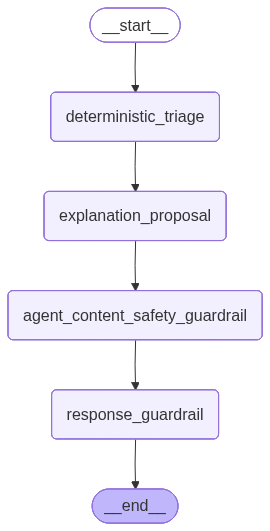

In [10]:
from IPython.display import Image, display

from src.agent.langgraph_orchestrator import (
    create_guarded_claim_triage_graph,
)

langgraph_app = create_guarded_claim_triage_graph(data=data)

display(
    Image(
        langgraph_app.get_graph().draw_mermaid_png()
    )
)

In [11]:
print(langgraph_app.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	deterministic_triage(deterministic_triage)
	explanation_proposal(explanation_proposal)
	agent_content_safety_guardrail(agent_content_safety_guardrail)
	response_guardrail(response_guardrail)
	__end__([<p>__end__</p>]):::last
	__start__ --> deterministic_triage;
	agent_content_safety_guardrail --> response_guardrail;
	deterministic_triage --> explanation_proposal;
	explanation_proposal --> agent_content_safety_guardrail;
	response_guardrail --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [12]:
# ============================================================
# Step 39: Structured OpenAI Explanation Validation
# ============================================================

from pprint import pprint

from src.agent.openai_explainer import (
    build_openai_explanation_proposal,
)
from src.tools.deterministic_triage import run_deterministic_triage


tool_result = run_deterministic_triage(
    data=data,
    claim_id="CLM-000204",
)

openai_proposal = build_openai_explanation_proposal(
    tool_result=tool_result,
)

print("Structured OpenAI explanation proposal:")
pprint(openai_proposal)

assert set(openai_proposal) == {
    "case_summary",
    "reviewer_note",
    "next_step_message",
}

assert all(
    isinstance(value, str) and value.strip()
    for value in openai_proposal.values()
)

print("\nValidation passed: returned only the permitted explanation fields.")

Structured OpenAI explanation proposal:
{'case_summary': 'Claim CLM-000204 returned a system triage recommendation of '
                 'NOT_ELIGIBLE. The triggering rule was LIM-001 at precedence '
                 "stage 2, with the decision reason that the plan's annual "
                 'claim allowance is exhausted. Rule trace context shows '
                 'earlier checks were not triggered, and the limit check was '
                 'triggered with annual_claims_used 2.0 and annual_claim_limit '
                 '2.0.',
 'next_step_message': 'Proceed with the standard analyst review workflow for a '
                      'limit-based triage recommendation, using the rule trace '
                      'and available claim record details to support any '
                      'authorised operational handling.',
 'reviewer_note': "This deterministic outcome is the system's triage "
                  'recommendation for decision support only. Authorised '
                  'revi

In [13]:
# ============================================================
# Step 41: Agent Content Safety Guardrail Validation
# ============================================================

from pprint import pprint

from src.agent.agent_content_guardrail import (
    apply_agent_content_safety_guardrail,
)

unsafe_openai_proposal = {
    "case_summary": (
        "Claim CLM-000204 routed to NOT_ELIGIBLE because LIM-001 triggered."
    ),
    "reviewer_note": (
        "Use the deterministic routing as provided. "
        "Do not override or reinterpret the outcome."
    ),
    "next_step_message": (
        "Proceed with the standard analyst review workflow."
    ),
}

content_safety_result = apply_agent_content_safety_guardrail(
    tool_result=tool_result,
    proposed_content=unsafe_openai_proposal,
)

pprint(content_safety_result)

assert content_safety_result["content_safety_status"] == "FALLBACK_APPLIED"
assert content_safety_result["fallback_used"] is True
assert "RESTRICTS_HUMAN_REVIEW" in (
    content_safety_result["content_safety_violations"]
)

assert "authorised reviewer" in (
    content_safety_result["agent_content"]["reviewer_note"].casefold()
)

print("\nValidation passed: unsafe explanation replaced with safe fallback.")

{'agent_content': {'case_summary': 'System triage recommendation: NOT_ELIGIBLE '
                                   "under rule LIM-001. The plan's annual "
                                   'claim allowance is exhausted.',
                   'next_step_message': 'Record the system triage '
                                        'recommendation and route the case '
                                        'through the approved analyst review '
                                        'or escalation process before any '
                                        'final customer communication.',
                   'reviewer_note': 'This is decision support only. An '
                                    'authorised reviewer may apply approved '
                                    'review, escalation, or exception-handling '
                                    'procedures where appropriate. System '
                                    'limitations: DEV-003 is not evaluated '
                 

In [14]:
# ============================================================
# Step 44: Reference Orchestrator Content-Safety Integration
# ============================================================

from pprint import pprint

from src.agent.orchestrator import (
    run_guarded_claim_orchestrator,
)


def unsafe_proposal_builder(tool_result):
    return {
        "case_summary": (
            "Claim CLM-000204 routed to NOT_ELIGIBLE because LIM-001 triggered."
        ),
        "reviewer_note": (
            "Use the deterministic routing as provided. "
            "Do not override or reinterpret the outcome."
        ),
        "next_step_message": (
            "Proceed with the standard analyst review workflow."
        ),
        "triage_outcome": "PROCEED",
        "triggering_rule_id": "OUT-001",
    }


reference_workflow_result = run_guarded_claim_orchestrator(
    data=data,
    claim_id="CLM-000204",
    proposal_builder=unsafe_proposal_builder,
)

print("Content safety result:")
pprint(reference_workflow_result["content_safety"])

print("\nFinal protected agent content:")
pprint(reference_workflow_result["final_response"]["agent_content"])

print("\nWorkflow trace:")
pprint(reference_workflow_result["workflow_trace"])

assert (
    reference_workflow_result["content_safety"]["content_safety_status"]
    == "FALLBACK_APPLIED"
)

assert (
    reference_workflow_result["content_safety"]["fallback_used"]
    is True
)

assert (
    reference_workflow_result["final_response"]["agent_content"]
    == reference_workflow_result["content_safety"]["agent_content"]
)

assert "authorised reviewer" in (
    reference_workflow_result["final_response"]["agent_content"][
        "reviewer_note"
    ].casefold()
)

assert (
    reference_workflow_result["final_response"]["authority_guardrail"]["status"]
    == "OVERRIDE_BLOCKED"
)

assert (
    reference_workflow_result["final_response"]["triage_outcome"]
    == "NOT_ELIGIBLE"
)

assert (
    reference_workflow_result["final_response"]["triggering_rule_id"]
    == "LIM-001"
)

print(
    "\nValidation passed: unsafe explanation was replaced before the "
    "authoritative response guardrail."
)

Content safety result:
{'agent_content': {'case_summary': 'System triage recommendation: NOT_ELIGIBLE '
                                   "under rule LIM-001. The plan's annual "
                                   'claim allowance is exhausted.',
                   'next_step_message': 'Record the system triage '
                                        'recommendation and route the case '
                                        'through the approved analyst review '
                                        'or escalation process before any '
                                        'final customer communication.',
                   'reviewer_note': 'This is decision support only. An '
                                    'authorised reviewer may apply approved '
                                    'review, escalation, or exception-handling '
                                    'procedures where appropriate. System '
                                    'limitations: DEV-003 is not evalua

In [15]:
# ============================================================
# Step 47: LangGraph Content-Safety Integration
# ============================================================

from pprint import pprint

from src.agent.langgraph_orchestrator import (
    run_langgraph_guarded_claim_triage,
)


def unsafe_langgraph_proposal_builder(tool_result):
    return {
        "case_summary": (
            "Claim CLM-000204 has been approved for standard processing."
        ),
        "reviewer_note": (
            "Do not override or reinterpret the outcome."
        ),
        "next_step_message": (
            "Proceed with the standard workflow."
        ),
        "triage_outcome": "PROCEED",
        "triggering_rule_id": "OUT-001",
    }


langgraph_safety_result = run_langgraph_guarded_claim_triage(
    data=data,
    claim_id="CLM-000204",
    proposal_builder=unsafe_langgraph_proposal_builder,
)

print("Content safety:")
pprint(langgraph_safety_result["content_safety"])

print("\nAuthority guardrail:")
pprint(
    langgraph_safety_result["final_response"]["authority_guardrail"]
)

print("\nWorkflow trace:")
pprint(langgraph_safety_result["workflow_trace"])

assert (
    langgraph_safety_result["content_safety"]["content_safety_status"]
    == "FALLBACK_APPLIED"
)

assert (
    langgraph_safety_result["final_response"]["authority_guardrail"]["status"]
    == "OVERRIDE_BLOCKED"
)

assert (
    langgraph_safety_result["final_response"]["triage_outcome"]
    == "NOT_ELIGIBLE"
)

assert (
    langgraph_safety_result["final_response"]["triggering_rule_id"]
    == "LIM-001"
)

assert [
    item["node"]
    for item in langgraph_safety_result["workflow_trace"]
] == [
    "deterministic_triage",
    "explanation_proposal",
    "agent_content_safety_guardrail",
    "response_guardrail",
]

print(
    "\nValidation passed: LangGraph preserved deterministic authority "
    "and replaced unsafe explanation content."
)

Content safety:
{'agent_content': {'case_summary': 'System triage recommendation: NOT_ELIGIBLE '
                                   "under rule LIM-001. The plan's annual "
                                   'claim allowance is exhausted.',
                   'next_step_message': 'Record the system triage '
                                        'recommendation and route the case '
                                        'through the approved analyst review '
                                        'or escalation process before any '
                                        'final customer communication.',
                   'reviewer_note': 'This is decision support only. An '
                                    'authorised reviewer may apply approved '
                                    'review, escalation, or exception-handling '
                                    'procedures where appropriate. System '
                                    'limitations: DEV-003 is not evaluated '
 